In [1]:
from langgraph.graph import StateGraph, START, END
from pydantic import BaseModel

# 1. State Definition
class State(BaseModel):
    state: str

# 2. Node & Logic Placeholders
def inputs(state: State): ...
def resume_screening(state: State): ...
def interview_condition(state: State): ... # Conditional Logic
def topics_node(state: State): ...
def question_node(state: State): ...
def interview_router(state: State): ...     # Conditional Logic
def resume_enhancements(state: State): ...
def final_evaluation(state: State): ...

# 3. Graph Construction
builder = StateGraph(State)

# Add Nodes
builder.add_node("inputs", inputs)
builder.add_node("resume_screening", resume_screening)
builder.add_node("topics_node", topics_node)
builder.add_node("question_node", question_node)
builder.add_node("resume_enhancements", resume_enhancements)
builder.add_node("final_evaluation", final_evaluation)

# 4. Define Edges and Routing
builder.add_edge(START, "inputs")
builder.add_edge("inputs", "resume_screening")

# Branch based on resume score
builder.add_conditional_edges(
    "resume_screening",
    interview_condition,
    {True: "topics_node", False: "resume_enhancements"}
)

builder.add_edge("topics_node", "question_node")

# Loop or Finish the interview
builder.add_conditional_edges(
    "question_node",
    interview_router,
    {
        "ask_again": "question_node",
        "next_topic": "question_node",
        "finish": "final_evaluation"
    }
)

builder.add_edge("resume_enhancements", END)
builder.add_edge("final_evaluation", END)


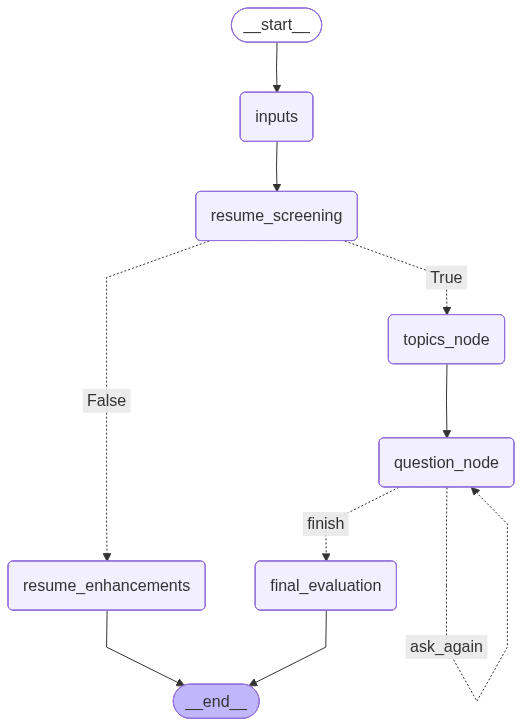

In [2]:
builder.compile()